# Конспект по PyTorch

### Тензоры и операции над ними

In [82]:
import torch
import numpy as np

torch.manual_seed(1)

In [83]:
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)

a_t = torch.tensor(a)
b_t = torch.tensor(b)

print(a_t)
print(b_t)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


In [84]:
t = torch.rand(3, 5)
print(t)
q = t.reshape(5, 3)
print(q)
w = torch.squeeze(t, 0)
print(t.shape, w.shape)

tensor([[0.7576, 0.2793, 0.4031, 0.7347, 0.0293],
        [0.7999, 0.3971, 0.7544, 0.5695, 0.4388],
        [0.6387, 0.5247, 0.6826, 0.3051, 0.4635]])
tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999],
        [0.3971, 0.7544, 0.5695],
        [0.4388, 0.6387, 0.5247],
        [0.6826, 0.3051, 0.4635]])
torch.Size([3, 5]) torch.Size([3, 5])


`torch.normal` — тензор из нормального распределения; `multiply` — поэлементное умножение.

In [85]:
t1 = 2*torch.rand(2, 5) - 1
t2 = torch.normal(mean=0, std=1, size=(2, 5))

t3 = torch.multiply(t1, t2)

print(t3)

tensor([[-0.0200,  0.0837,  0.0070,  0.1979, -0.0733],
        [-0.1124,  0.1673, -0.0800,  0.0476, -0.0934]])


### Dataloader

`DataLoader` разбивает данные на батчи (по умолчанию `batch_size=1`).

In [86]:
from torch.utils.data import DataLoader

In [87]:
t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)

In [88]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


`batch_size` задаёт размер батча, `shuffle=True` перемешивает данные.

In [89]:
data_loader = DataLoader(t, batch_size=3, shuffle=True)

for item in data_loader:
    print(item)    

tensor([5., 0., 1.])
tensor([3., 4., 2.])


Часто бывает так, что данные хранятся в двух (или более) тензорах. Например, у нас
может быть тензор для признаков и тензор для меток. В таких случаях нужно построить набор данных, объединяющий эти тензоры, что позволит извлекать элементы тензоров в кортежах.
Предположим, что у нас есть два тензора: t_x и t_y. Тензор t_x содержит значения признаков, каждое размером 3, а тензор t _У хранит метки классов.

Признаки и метки: `t_x` — 4 примера по 3 признака, `t_y` — метки классов.

In [90]:
t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

Свой `Dataset`: `__len__` — размер, `__getitem__` — пара (x, y) по индексу.

In [91]:
from torch.utils.data import Dataset 
class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

Итерация по `Dataset` возвращает кортежи (признаки, метка).

In [92]:
from torch.utils.data import TensorDataset
joint_dataset = JointDataset(t_x, t_y)

for example in joint_dataset:
    print(f'x: {example[0]}, y: {example[1]}')

x: tensor([0.2616, 0.7713, 0.3785]), y: 0
x: tensor([0.9980, 0.9008, 0.4766]), y: 1
x: tensor([0.1663, 0.8045, 0.6552]), y: 2
x: tensor([0.1768, 0.8248, 0.8036]), y: 3


или проще

`TensorDataset` делает то же самое без собственного класса.

In [93]:
joint_dataset = TensorDataset(t_x, t_y)

In [94]:
print(joint_dataset)

Передаём `Dataset` в `DataLoader` — получаем батчи пар (x, y).

In [95]:
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True) 

for i, batch in enumerate(data_loader, 1):
    print (f'batch {i}: ', 'x: ', batch[0],'\n y:', batch[1])


batch 1:  x:  tensor([[0.1663, 0.8045, 0.6552],
        [0.2616, 0.7713, 0.3785]]) 
 y: tensor([2, 0])
batch 2:  x:  tensor([[0.9980, 0.9008, 0.4766],
        [0.1768, 0.8248, 0.8036]]) 
 y: tensor([1, 3])


In [96]:
import pathlib
imgdir_path = pathlib.Path('cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])

print(file_list)


['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Размеры изображения cat_dog_images\cat-01.jpg: (1200, 900)
Размеры изображения cat_dog_images\cat-02.jpg: (1200, 900)
Размеры изображения cat_dog_images\cat-03.jpg: (742, 900)
Размеры изображения cat_dog_images\dog-01.jpg: (1200, 800)
Размеры изображения cat_dog_images\dog-02.jpg: (1200, 800)
Размеры изображения cat_dog_images\dog-03.jpg: (1200, 900)


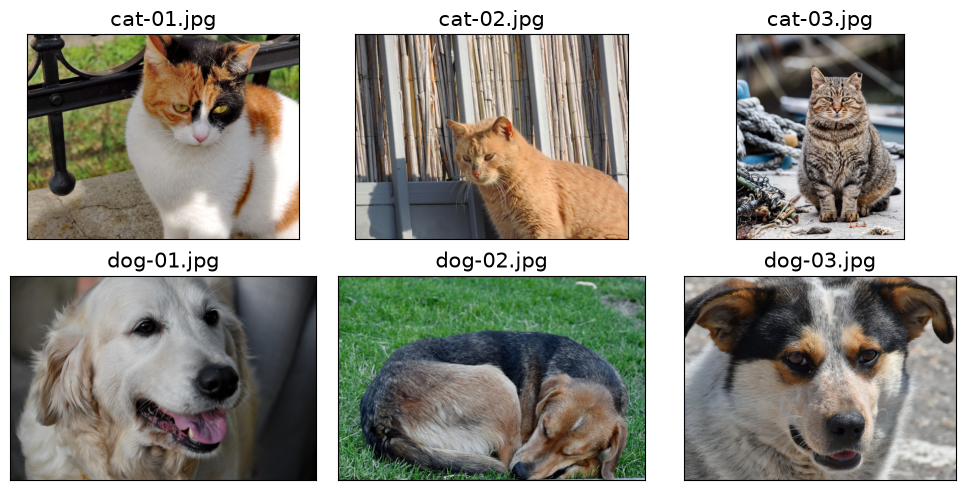

In [97]:
import matplotlib.pyplot as plt
import os 
from PIL import Image

fig = plt.figure(figsize=(10, 5)) 
for i, file in enumerate(file_list):
    img = Image.open(file)
    print(f'Размеры изображения {file}: {img.size}')
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)

plt.tight_layout() 
plt.show()

Метки: 1 — собака, 0 — кошка.

In [98]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]

print(labels)

[0, 0, 0, 1, 1, 1]


Класс `Dataset` для изображений: по индексу возвращает (путь, метка).

In [99]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels       

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file = self.file_list[idx]
        label = self.labels[idx] 
        return file, label

In [100]:
image_dataset = ImageDataset(file_list, labels) 
for file, label in image_dataset:
    print(file, label)

cat_dog_images\cat-01.jpg 0
cat_dog_images\cat-02.jpg 0
cat_dog_images\cat-03.jpg 0
cat_dog_images\dog-01.jpg 1
cat_dog_images\dog-02.jpg 1
cat_dog_images\dog-03.jpg 1


`transforms` превращает картинку в тензор и меняет размер; класс возвращает готовое изображение-тензор.

In [101]:
import torchvision.transforms as transforms
img_height, img_width = 80, 120

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

# Обновим класс

class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img = Image.open(self.file_list[idx])
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


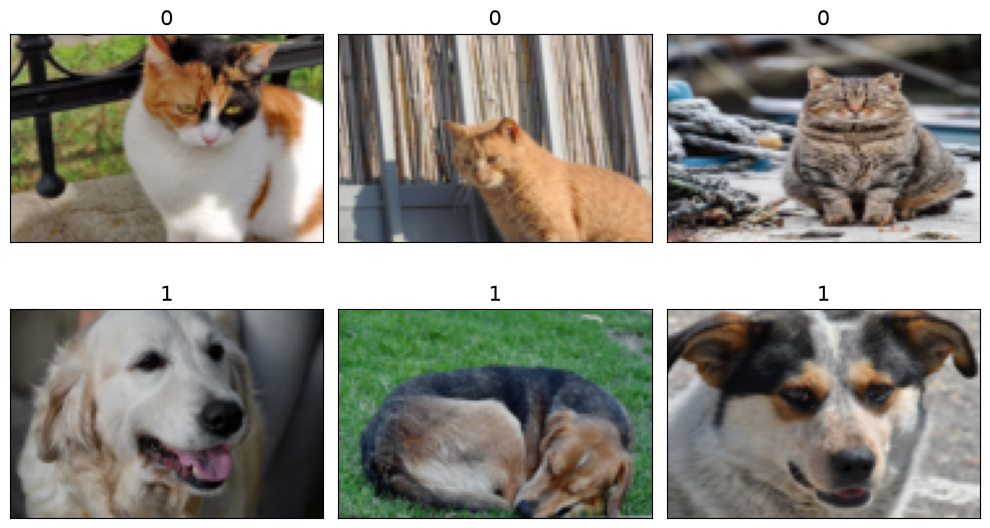

In [ ]:
image_dataset = ImageDataset(file_list, labels, transform)

fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([]) 
    ax.imshow(example[0].numpy().transpose(1, 2, 0))
    ax.set_title(f'{example[1]}', size=15) 

plt.tight_layout()
plt.show() 